Comp 3610 Assignment 4
Part 1 - Experiment Tracking with MLflow

In [13]:
import numpy as np
import pandas as pd
import math, os, time
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import mlflow
import mlflow.sklearn

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH = 'cleaned_taxi_data.parquet'
ZONE_PATH = 'taxi_zone_lookup.csv'

df_raw = pd.read_parquet(DATA_PATH)
zone_df = pd.read_csv(ZONE_PATH)
loc_to_borough = zone_df.set_index('LocationID')['Borough'].to_dict()

df = df_raw[df_raw['payment_type'] == 1].copy()

for col in ['tpep_pickup_datetime', 'tpep_dropoff_datetime']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

print(f"Rows after credit card filter: {len(df):,}")


Rows after credit card filter: 2,241,617


In [14]:
def engineering_features(df, loc_to_borough):
    df = df.copy()
    df['pickup_hour']           = df['tpep_pickup_datetime'].dt.hour
    df['pickup_day_of_week']    = df['tpep_pickup_datetime'].dt.dayofweek
    df['is_weekend']            = (df['pickup_day_of_week'] >= 5).astype(int)
    df['trip_duration_minutes'] = (
        (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
    )
    df['trip_speed_mph'] = np.where(
        df['trip_duration_minutes'] > 0,
        df['trip_distance'] / (df['trip_duration_minutes'] / 60), np.nan
    )
    df['log_trip_distance'] = np.log1p(df['trip_distance'])
    df['fare_per_mile']     = np.where(df['trip_distance'] > 0,
                                       df['fare_amount'] / df['trip_distance'], np.nan)
    df['fare_per_minute']   = np.where(df['trip_duration_minutes'] > 0,
                                       df['fare_amount'] / df['trip_duration_minutes'], np.nan)
    le = LabelEncoder()
    df['pickup_borough']     = df['PULocationID'].map(loc_to_borough).fillna('Unknown')
    df['dropoff_borough']    = df['DOLocationID'].map(loc_to_borough).fillna('Unknown')
    df['pickup_borough_enc'] = le.fit_transform(df['pickup_borough'])
    df['dropoff_borough_enc']= le.fit_transform(df['dropoff_borough'])
    return df

df = engineering_features(df, loc_to_borough)

FEATURE_COLS = [
    'pickup_hour', 'pickup_day_of_week', 'is_weekend',
    'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance',
    'trip_distance', 'passenger_count', 'fare_amount',
    'fare_per_mile', 'fare_per_minute', 'extra', 'mta_tax',
    'tolls_amount', 'improvement_surcharge',
    'pickup_borough_enc', 'dropoff_borough_enc', 'RatecodeID',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

df_model = df[FEATURE_COLS + ['tip_amount']].dropna()
X = df_model[FEATURE_COLS]
y = df_model['tip_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Train: 1,793,293  |  Test: 448,324


In [15]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("taxi-tip-prediction")
print("MLflow experiment set: taxi-tip-prediction")

MLflow experiment set: taxi-tip-prediction


In [16]:
def log_regression_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mlflow.log_metric("mae",  mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2",   r2)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

In [17]:
with mlflow.start_run(run_name="linear-regression"):
    params = {"fit_intercept": True}
    mlflow.log_params(params)
    mlflow.set_tag("model_type", "LinearRegression")
    mlflow.set_tag("dataset_version", "v1")

    lr = LinearRegression(**params)
    lr.fit(X_train_scaled, y_train)
    preds = lr.predict(X_test_scaled)

    metrics_lr = log_regression_metrics(y_test, preds)
    mlflow.sklearn.log_model(lr, "model",
                             registered_model_name="taxi-tip-regressor")

    print("Linear Regression logged.")
    print(f"  MAE={metrics_lr['MAE']:.4f}  RMSE={metrics_lr['RMSE']:.4f}  R2={metrics_lr['R2']:.4f}")

2026/04/18 09:31:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 09:31:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'taxi-tip-regressor' already exists. Creating a new version of this model...
2026/04/18 09:31:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 3
Created version '3' of model 'taxi-tip-regressor'.


Linear Regression logged.
  MAE=1.2072  RMSE=2.3913  R2=0.6178
🏃 View run linear-regression at: http://localhost:5000/#/experiments/880846622387795464/runs/2f6375ed4b324f4dbef809702568b8c1
🧪 View experiment at: http://localhost:5000/#/experiments/880846622387795464


In [18]:
RF_SAMPLE = 100_000
X_rf = X_train_scaled[:RF_SAMPLE]
y_rf = y_train.iloc[:RF_SAMPLE]

with mlflow.start_run(run_name="random-forest-regressor"):
    params = {"n_estimators": 30, "max_depth": 10, "random_state": 42}
    mlflow.log_params(params)
    mlflow.set_tag("model_type", "RandomForestRegressor")
    mlflow.set_tag("dataset_version", "v1")
    mlflow.set_tag("note", "Trained on 100k sample due to runtime constraints")

    rf = RandomForestRegressor(**params, n_jobs=-1)
    rf.fit(X_rf, y_rf)
    preds_rf = rf.predict(X_test_scaled)

    metrics_rf = log_regression_metrics(y_test, preds_rf)
    mlflow.sklearn.log_model(rf, "model")

    print("Random Forest logged.")
    print(f"  MAE={metrics_rf['MAE']:.4f}  RMSE={metrics_rf['RMSE']:.4f}  R2={metrics_rf['R2']:.4f}")

2026/04/18 09:32:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 09:32:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Random Forest logged.
  MAE=1.2041  RMSE=2.4198  R2=0.6087
🏃 View run random-forest-regressor at: http://localhost:5000/#/experiments/880846622387795464/runs/d606c3e537234901ac9e1606d4ccf79c
🧪 View experiment at: http://localhost:5000/#/experiments/880846622387795464


Part 1.2 - Model Comparison and Registry

Comparison of Linear Regression and Random Forest
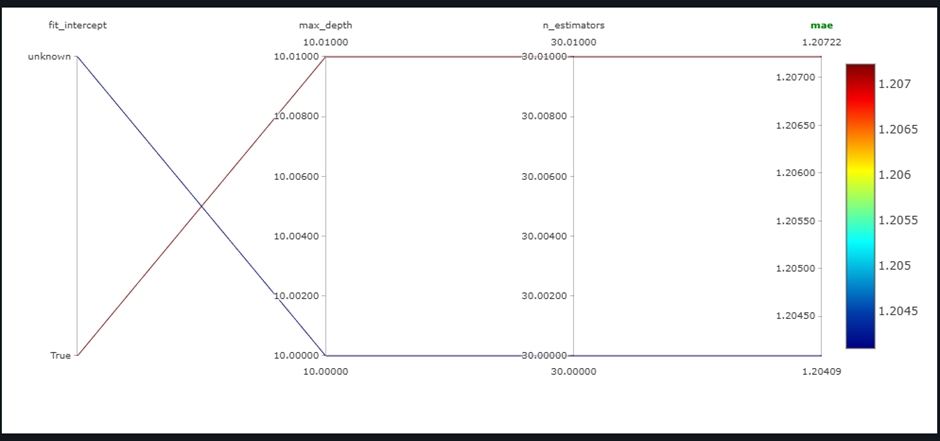

In [19]:
experiment = mlflow.get_experiment_by_name("taxi-tip-prediction")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
print(runs[["run_id", "tags.mlflow.runName", "metrics.mae", "metrics.rmse", "metrics.r2"]]
      .sort_values("metrics.mae"))

                             run_id      tags.mlflow.runName  metrics.mae  \
0  d606c3e537234901ac9e1606d4ccf79c  random-forest-regressor     1.204086   
2  aabb27e89b3e4475b58a679561008e46  random-forest-regressor     1.204086   
4  6e2f60cbf45d4061a5ba3ed90313ad0a  random-forest-regressor     1.204086   
1  2f6375ed4b324f4dbef809702568b8c1        linear-regression     1.207217   
3  047cdfe916ec478f9e2bf5fd2d34ef8f        linear-regression     1.207217   
5  6744e868d46c470996898011be75650a        linear-regression     1.207217   

   metrics.rmse  metrics.r2  
0      2.419755    0.608710  
2      2.419755    0.608710  
4      2.419755    0.608710  
1      2.391343    0.617845  
3      2.391343    0.617845  
5      2.391343    0.617845  


In [20]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

client.set_registered_model_alias(
    name="taxi-tip-regressor",
    alias="Production",
    version="1"
)
print("Version 1 set as Production alias.")

Version 1 set as Production alias.


In [21]:
import mlflow
import joblib
import numpy as np

mlflow.set_tracking_uri("http://localhost:5000")

loaded_model = mlflow.sklearn.load_model("models:/taxi-tip-regressor@Production")

sample = X_test_scaled[:1]
predicted_tip = loaded_model.predict(sample)[0]
print(f"Sample prediction from registry model: ${predicted_tip:.2f}")
print(f"Actual tip:                             ${y_test.iloc[0]:.2f}")

Sample prediction from registry model: $2.21
Actual tip:                             $2.00


In [22]:
import os
os.makedirs("models", exist_ok=True)
joblib.dump(lr,     "models/linear_regression.pkl")
joblib.dump(scaler, "models/scaler.pkl")
print("Models saved to models/ directory.")

Models saved to models/ directory.


Part 2 : Model Serving with FastAPI
the full api is in app.py

In [23]:
# Server started in terminal with:
# uvicorn app:app --reload --port 8000
# Running at http://localhost:8000
print("API running at http://localhost:8000")

API running at http://localhost:8000


In [24]:
import requests

payload = {
    "pickup_hour": 14, "pickup_day_of_week": 2, "is_weekend": 0,
    "trip_duration_minutes": 12.5, "trip_speed_mph": 18.4,
    "log_trip_distance": 1.35, "trip_distance": 3.2,
    "passenger_count": 1, "fare_amount": 13.5,
    "fare_per_mile": 4.22, "fare_per_minute": 1.08,
    "extra": 0.5, "mta_tax": 0.5, "tolls_amount": 0.0,
    "improvement_surcharge": 0.3,
    "pickup_borough_enc": 3, "dropoff_borough_enc": 2, "RatecodeID": 1,
}

r = requests.post("http://localhost:8000/predict", json=payload)
print(r.status_code, r.json())

200 {'tip_amount': 3.48, 'prediction_id': '5c7fb6e9-ade3-47bc-b0a2-5c709a6d938d', 'model_version': '1.0.0'}


In [25]:
batch_payload = {"records": [payload] * 3}
r = requests.post("http://localhost:8000/predict/batch", json=batch_payload)
print(r.status_code, r.json())

200 {'predictions': [{'tip_amount': 3.48, 'prediction_id': '7557be7f-8228-40da-ba73-ae924dc5adde', 'model_version': '1.0.0'}, {'tip_amount': 3.48, 'prediction_id': 'ce4dceb9-25f3-4d90-be25-91c05c5188da', 'model_version': '1.0.0'}, {'tip_amount': 3.48, 'prediction_id': '6cdf555a-5270-48ac-8a87-36dd628b193f', 'model_version': '1.0.0'}], 'count': 3, 'processing_time_ms': 7.53}


In [26]:
print(requests.get("http://localhost:8000/health").json())
print(requests.get("http://localhost:8000/model/info").json())

{'status': 'healthy', 'model_loaded': True, 'model_version': '1.0.0', 'uptime_seconds': 340.2}
{'model_name': 'taxi-tip-regressor', 'version': '1.0.0', 'features': ['pickup_hour', 'pickup_day_of_week', 'is_weekend', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'trip_distance', 'passenger_count', 'fare_amount', 'fare_per_mile', 'fare_per_minute', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'pickup_borough_enc', 'dropoff_borough_enc', 'RatecodeID'], 'metrics': {'MAE': 1.21, 'RMSE': 2.39, 'R2': 0.62}, 'trained_on': 'NYC Yellow Taxi - January 2024 (credit card payments)'}


Part 2.3 : Api Testing
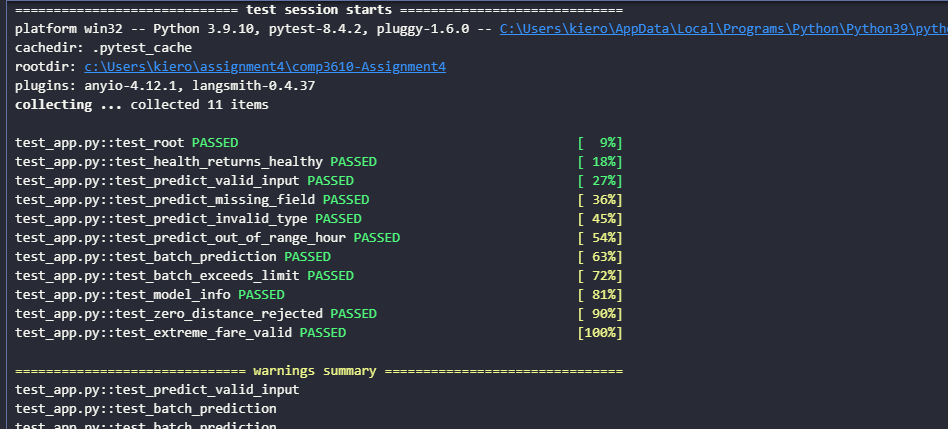

In [28]:
!pytest test_app.py -v

============================= test session starts =============================
platform win32 -- Python 3.9.10, pytest-8.4.2, pluggy-1.6.0 -- C:\Users\kiero\AppData\Local\Programs\Python\Python39\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\kiero\assignment4\comp3610-Assignment4
plugins: anyio-4.12.1, langsmith-0.4.37
collecting ... collected 11 items

test_app.py::test_root PASSED                                            [  9%]
test_app.py::test_health_returns_healthy PASSED                          [ 18%]
test_app.py::test_predict_valid_input PASSED                             [ 27%]
test_app.py::test_predict_missing_field PASSED                           [ 36%]
test_app.py::test_predict_invalid_type PASSED                            [ 45%]
test_app.py::test_predict_out_of_range_hour PASSED                       [ 54%]
test_app.py::test_batch_prediction PASSED                                [ 63%]
test_app.py::test_batch_exceeds_limit PASSED                             [ 7